Original data shape: (2000, 6)
Reduced data shape after PCA: (2000, 2)
Explained variance ratio: [0.5736 0.3006]
Total variance captured: 0.8743
PCA Component Loadings:
Intensity  PC1 = 0.1916  PC2 = 0.6818
Gradient  PC1 = 0.4831  PC2 = -0.1533
LocalMean  PC1 = 0.1995  PC2 = 0.6768
LocalStd  PC1 = 0.4932  PC2 = -0.1452
Laplacian  PC1 = 0.4253  PC2 = -0.0998
Range  PC1 = 0.5157  PC2 = -0.1503
PCA Cluster Centre (Non-Boundary): [-0.4844  0.2575]
PCA Cluster Centre (Boundary): [ 0.4844 -0.2575]
Reduced data shape after t-SNE: (2000, 2)
KL Divergence: 0.8707
t-SNE Cluster Centre (Non-Boundary): [-4.6369  4.2228]
t-SNE Cluster Centre (Boundary): [ 6.4561 -3.4177]


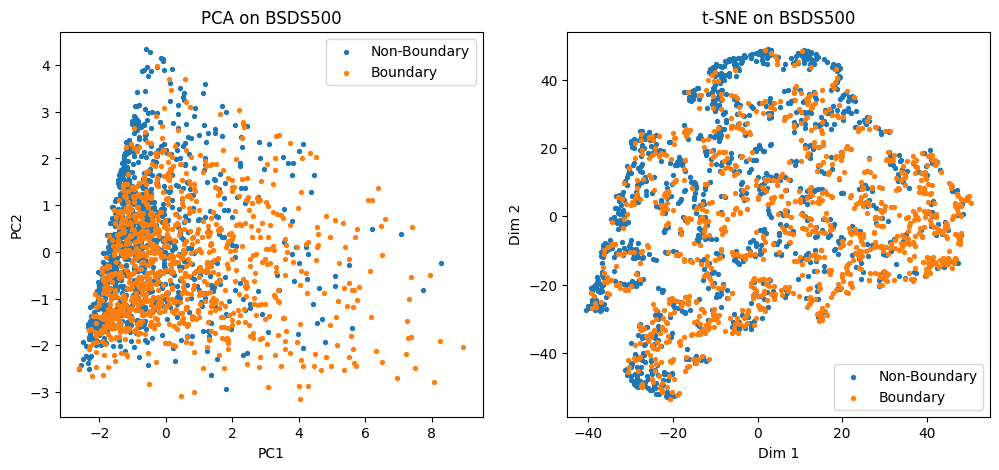

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.io import loadmat
from scipy.ndimage import uniform_filter, sobel, laplace, maximum_filter, minimum_filter
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import kagglehub

path = kagglehub.dataset_download("balraj98/berkeley-segmentation-dataset-500-bsds500")

images = sorted(glob.glob(path + "/**/*.jpg", recursive=True))
gtmap = {}
for m in glob.glob(path + "/**/*.mat", recursive=True):
    gtmap[os.path.basename(m)[:-4]] = m

names = ["Intensity", "Gradient", "LocalMean", "LocalStd", "Laplacian", "Range"]


def get_features(f):
    g = np.array(Image.open(f).convert("L"), dtype=float) / 255.0
    gx = sobel(g, axis=0)
    gy = sobel(g, axis=1)
    grad = np.sqrt(gx * gx + gy * gy)
    mean = uniform_filter(g, 5)
    std = np.sqrt(np.abs(uniform_filter(g * g, 5) - mean * mean))
    lap = np.abs(laplace(g))
    rng = maximum_filter(g, 3) - minimum_filter(g, 3)
    F = np.stack([g, grad, mean, std, lap, rng], axis=2)
    return F.reshape(-1, 6), g.shape


def get_labels(name, shape):
    d = loadmat(gtmap[name])["groundTruth"]
    b = np.zeros(shape)
    for i in range(d.shape[1]):
        b = b + d[0, i]["Boundaries"][0, 0]
    return (b > 0).astype(int).reshape(-1)


def build_dataset(n_images, per_class):
    X = []
    Y = []
    for f in images[:n_images]:
        name = os.path.basename(f)[:-4]
        if name not in gtmap:
            continue
        F, shape = get_features(f)
        L = get_labels(name, shape)
        pos = np.where(L == 1)[0]
        neg = np.where(L == 0)[0]
        k = min(per_class, len(pos), len(neg))
        if k == 0:
            continue
        pos = np.random.choice(pos, k, replace=False)
        neg = np.random.choice(neg, k, replace=False)
        idx = np.concatenate([pos, neg])
        X.append(F[idx])
        Y.append(L[idx])
    return np.vstack(X), np.concatenate(Y)


np.random.seed(1)
X, y = build_dataset(20, 50)
X = StandardScaler().fit_transform(X)

print("Original data shape:", X.shape)

pca = PCA(n_components=2)
Xp = pca.fit_transform(X)

print("Reduced data shape after PCA:", Xp.shape)
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))
print("Total variance captured:", round(pca.explained_variance_ratio_.sum(), 4))

print("PCA Component Loadings:")
for i in range(len(names)):
    print(names[i], " PC1 =", round(pca.components_[0][i], 4), " PC2 =", round(pca.components_[1][i], 4))

print("PCA Cluster Centre (Non-Boundary):", np.round(Xp[y == 0].mean(axis=0), 4))
print("PCA Cluster Centre (Boundary):", np.round(Xp[y == 1].mean(axis=0), 4))

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
Xt = tsne.fit_transform(X)

print("Reduced data shape after t-SNE:", Xt.shape)
print("KL Divergence:", round(tsne.kl_divergence_, 4))
print("t-SNE Cluster Centre (Non-Boundary):", np.round(Xt[y == 0].mean(axis=0), 4))
print("t-SNE Cluster Centre (Boundary):", np.round(Xt[y == 1].mean(axis=0), 4))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(Xp[y == 0][:, 0], Xp[y == 0][:, 1], s=8, label="Non-Boundary")
ax[0].scatter(Xp[y == 1][:, 0], Xp[y == 1][:, 1], s=8, label="Boundary")
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")
ax[0].set_title("PCA on BSDS500")
ax[0].legend()
ax[1].scatter(Xt[y == 0][:, 0], Xt[y == 0][:, 1], s=8, label="Non-Boundary")
ax[1].scatter(Xt[y == 1][:, 0], Xt[y == 1][:, 1], s=8, label="Boundary")
ax[1].set_xlabel("Dim 1")
ax[1].set_ylabel("Dim 2")
ax[1].set_title("t-SNE on BSDS500")
ax[1].legend()
plt.show()
